# 1. Defining Tokenizer, Loading, Filterning and Preprocessing Text

In [26]:
import re
import pandas as pd
from datasets import load_dataset
from tqdm import tqdm

import pandas as pd
import urllib.request
import io

def comprehensive_cleaner(text, is_arabic=True):
    """Removes noise, normalizes Arabic, and squashes whitespace."""
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'http\S+|www\S+', '<URL>', text)
    
    if is_arabic:
        text = re.sub(r'[\u064B-\u065F]', '', text) # Diacritics
        text = re.sub(r'\u0640', '', text)         # Tatweel
        text = re.sub(r'[إأآا]', 'ا', text)        # Alif
        text = re.sub(r'ى', 'ي', text)             # Alef Maksura
        text = re.sub(r'ة', 'ه', text)             # Taa Marbuta
        text = re.sub(r'[«»]', '"', text)          # Quotes
        text = re.sub(r'،', ',', text)             # Comma
        text = re.sub(r'؟', '?', text)             # Question mark
        eastern_to_western = str.maketrans('٠١٢٣٤٥٦٧٨٩', '0123456789')
        text = text.translate(eastern_to_western)
        
    # Standardize multiple hyphens to a single dash, and multiple dots to a standard ellipsis
    # It standardizes the punctuation so the BPE tokenizer doesn't waste vocabulary slots on variations like '--', '---', '..', and '....'.
    text = re.sub(r'-{2,}', '-', text)  # Turns '--' or '---' into '-'
    text = re.sub(r'\.{2,}', '...', text) # Turns '..' or '....' into '...'
    
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

def is_valid_alphabet(en_text, ar_text):
    """Drops pairs containing Chinese, Hindi, Russian, etc."""
    # Allows Latin, numbers, punctuation
    en_pattern = re.compile(r'^[a-zA-Z0-9\s\.,!\?\'"()\-:;/%$€]+$')
    # Allows Arabic, numbers, punctuation
    ar_pattern = re.compile(r'^[\u0600-\u06FF0-9\s\.,!\?\'"()\-:;/%$€]+$')
    
    if en_pattern.match(en_text) and ar_pattern.match(ar_text):
        return True
    return False

In [36]:
import re
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace

def train_bpe_tokenizer(sentences, vocab_size=10000, save_path="tokenizer.json"):
    """
    Trains a BPE tokenizer from scratch to strictly control the embedding matrix size.
    """
    # Initialize a Byte-Pair Encoding model
    tokenizer = Tokenizer(BPE(unk_token="[UNK]"))
    tokenizer.pre_tokenizer = Whitespace()
    
    # Define special tokens required for Seq2Seq
    trainer = BpeTrainer(
        vocab_size=vocab_size,
        special_tokens=["[PAD]", "[UNK]", "[SOS]", "[EOS]"]
    )
    
    # Train directly on the in-memory list of sentences
    tokenizer.train_from_iterator(sentences, trainer=trainer)
    tokenizer.save(save_path)
    
    return tokenizer

# 2. Loading the and Filtering the Data from the 3 sources

In [28]:
def extract_hf_pairs(hf_repo, config_name, num_samples):
    """Safely extracts data from Hugging Face Parquet datasets."""
    dataset = load_dataset(hf_repo, config_name, split="train", streaming=True)
    shuffled = dataset.shuffle(seed=42, buffer_size=10000)
    
    en_list, ar_list = [], []
    sample_iterator = iter(shuffled)
    
    with tqdm(total=num_samples, desc=f"Fetching {hf_repo}") as pbar:
        while len(en_list) < num_samples:
            try:
                row = next(sample_iterator)
                if 'translation' in row:
                    en_text = row['translation']['en']
                    ar_text = row['translation']['ar']
                else:
                    en_text = row.get('en', '')
                    ar_text = row.get('ar', '')
                
                if en_text and ar_text:
                    en_list.append(en_text)
                    ar_list.append(ar_text)
                    pbar.update(1)
            except StopIteration:
                print(f"Warning: Reached end of dataset before hitting {num_samples} samples.")
                break
                
    return en_list, ar_list

def build_and_filter_master_dataset(custom_file_path=None, max_len=30):
    """Builds the raw dataset and immediately applies all strict filters."""
    raw_en = []
    raw_ar = []
    
    # 1. OPUS-100 (Subtitles, TED, Gen Text) - 80k
    en, ar = extract_hf_pairs("Helsinki-NLP/opus-100", "ar-en", 80000)
    raw_en.extend(en); raw_ar.extend(ar)
    
    # 2. News Commentary (Formal MSA) - 20k
    en, ar = extract_hf_pairs("news_commentary", "ar-en", 20000)
    raw_en.extend(en); raw_ar.extend(ar)
    
    # 3. Custom Local Dataset
    if custom_file_path:
        try:
            custom_df = pd.read_csv(custom_file_path, sep='\t', header=None, names=['en', 'ar']).dropna()
            raw_en.extend(custom_df['en'].astype(str).tolist())
            raw_ar.extend(custom_df['ar'].astype(str).tolist())
            print(f"Added {len(custom_df)} pairs from local file.")
        except Exception as e:
            print(f"Could not load local file: {e}")

    print(f"\n--- Starting Aggressive Filtering on {len(raw_en)} raw pairs ---")
    
    final_en = []
    final_ar = []

    invalid_pairs_count = 0
    for en, ar in tqdm(zip(raw_en, raw_ar), total=len(raw_en), desc="Cleaning & Filtering"):
        # Step A: Clean strings
        clean_en = comprehensive_cleaner(en, is_arabic=False)
        clean_ar = comprehensive_cleaner(ar, is_arabic=True)
        
        # Step B: Drop foreign alphabets
        if not is_valid_alphabet(clean_en, clean_ar):
            invalid_pairs_count += 1
            continue
            
        # Step C: Word bounds (<= 30) AND Character bounds (> 1) to drop empty/dash pairs
        en_words = clean_en.split()
        ar_words = clean_ar.split()
        
        if 0 < len(en_words) <= max_len and 0 < len(ar_words) <= max_len:
            if len(clean_en) > 1 and len(clean_ar) > 1:
                final_en.append(clean_en)
                final_ar.append(clean_ar)
    print(f"\nInvalid pairs count = {invalid_pairs_count}")            
    print(f"\nPipeline Complete! Yielded {len(final_en)} pristine, NMT-ready pairs.")
    return final_en, final_ar

### 2.a Exploring and Experimenting with the Data

In [29]:
url = "https://raw.githubusercontent.com/SamirMoustafa/nmt-with-attention-for-ar-to-en/master/ara_.txt"
response = urllib.request.urlopen(url)
raw_text = response.read().decode('utf-8')
# Convert string to file-like object
custom_file = io.StringIO(raw_text)
final_en_data, final_ar_data = build_and_filter_master_dataset(custom_file)

Fetching news_commentary: 100%|██████████| 20000/20000 [00:04<00:00, 4001.99it/s]


Added 10742 pairs from local file.

--- Starting Aggressive Filtering on 110742 raw pairs ---


Cleaning & Filtering: 100%|██████████| 110742/110742 [00:07<00:00, 14271.27it/s]


Invalid pairs count = 17417

Pipeline Complete! Yielded 83171 pristine, NMT-ready pairs.


### 2.b Understanding Diacritics and Tatweel 

In [11]:
print('=> Diacritics (Tashkeel)\n')
print('\u064B    \u065C    \u065D    \u065E    \u065F \n')
print('=> Example on "TATWEEL"')
print('   -- With TATWEEL: \u0646\u0640\u0640\u0640\u0639\u0640\u0640\u0640\u0645') # '\u0640' special character for TATWEEL ('it adds something like a connected hiphen') 
print('   -- After removing TATWEEL: \u0646\u0639\u0645')

=> Diacritics (Tashkeel)

ً    ٜ    ٝ    ٞ    ٟ 

=> Example on "TATWEEL"
   -- With TATWEEL: نـــعـــم
   -- After removing TATWEEL: نعم


### 2.c Experimenting with the Local Dataset

In [10]:
import pandas as pd
import urllib.request
import io

url = "https://raw.githubusercontent.com/SamirMoustafa/nmt-with-attention-for-ar-to-en/master/ara_.txt"

response = urllib.request.urlopen(url)
raw_text = response.read().decode('utf-8')

# Convert string to file-like object
data = io.StringIO(raw_text)

df = pd.read_csv(data, sep='\t', header=None, names=['english', 'arabic'])
local_data_length = len(df)
print("Local Data Length: ", local_data_length)
pd.DataFrame(pd.concat([df.head(), df.tail(2)]))

Local Data Length:  10742


,english,arabic
0,Hi.,مرحبًا.
1,Run!,اركض!
2,Help!,النجدة!
3,Jump!,اقفز!
4,Stop!,قف!
10740,"Ladies and gentlemen, please stand for the nat...",سيداتي و سادتي ، رجاءً قفوا للنشيد الوطني للات...
10741,There are mothers and fathers who will lie awa...,وهناك أمهات وآباء سيظلون مستيقظين بعد أن ينام ...


In [30]:
TRAINING_PAIRS_COUNT = len(final_en_data)
SOURCES = {"Helsinki-NLP/opus-100": 80000,
           "news_commentary": 20000,
           "github.com/SamirMoustafa/nmt-with-attention-for-ar-to-en/blob/master/ara_.txt": local_data_length
          }
print(TRAINING_PAIRS_COUNT)
print(SOURCES)

83171
{'Helsinki-NLP/opus-100': 80000, 'news_commentary': 20000, 'github.com/SamirMoustafa/nmt-with-attention-for-ar-to-en/blob/master/ara_.txt': 10742}


### 2.d Visualizing the Effect of applying Standardization on the number of Hyphens and Dots in the comprehensive_cleaner
### `(a) Before applying standardization:`

In [31]:
two_or_more_hyphens = []
two_or_more_dots = []
for sentence in final_en_data:
    if '--' in sentence:
        two_or_more_hyphens.append(sentence)
    if '..' in sentence:
        two_or_more_dots.append(sentence)
print("Number of sentences having two or more Hyphens",len(two_or_more_hyphens))
print("Number of sentences having two or more Dots",len(two_or_more_dots))

Number of sentences having two or more Hyphens 0
Number of sentences having two or more Dots 4078


In [87]:
print("Sample of sentences having two or more Hyphens, with count = ",len(two_or_more_hyphens))
two_or_more_hyphens[:20]

Sample of sentences having two or more Hyphens, with count =  405


['You get little pieces of green paper called money...',
 "You shouldn't.. Let him read it.",
 'Pah get out of here fast..',
 '- Yeah... - Yeah?',
 'He filled her with poison and began speaking in tongue... satanic words.',
 'Sir..',
 "Don't you touch my...!",
 'But...',
 'Either I get a text, or an e-mail, or something official...',
 'Mary Todd... will you make me the happiest of men?',
 'New York, London, Paris, Beijing... and...',
 'Ca...',
 'Well... do--uh...',
 "You're so angry that...",
 'michael Jackson, Gene kelly...',
 'I could fall in love with you, you know. Uh...',
 'So...',
 "You... you're obviously very nice for...",
 'Centaur...',
 'Toby Follet fromAnjuna..',
 "I mean, we've been going out for years, and all of a sudden... bang... she drops me.",
 'You have that right, but if...',
 'Otherwise...',
 'Well, desperate times...',
 "Yeah, the folks at Global Tetrahedron thought he'd be... you know, a fun, unobtrusive way to plug the company during the news.",
 'Sir, if... loo

### (b) `After Applying Standardization:`

In [ ]:
two_or_more_hyphens = []
two_or_more_dots = []
for sentence in final_en_data:
    if '--' in sentence:
        two_or_more_hyphens.append(sentence)
    if '..' in sentence:
        two_or_more_dots.append(sentence)
print("Number of sentences having two or more Hyphens",len(two_or_more_hyphens))
print("Number of sentences having two or more Dots",len(two_or_more_dots))

### 2.e Plotting the Count of sentences with each Length of words, from 1 to 30

In [64]:
en_sentences_length = []
ar_sentences_length = []
for i in range(len(final_en_data)):
    en_sentences_length.append(len(final_en_data[i].split()))
    ar_sentences_length.append(len(final_ar_data[i].split()))

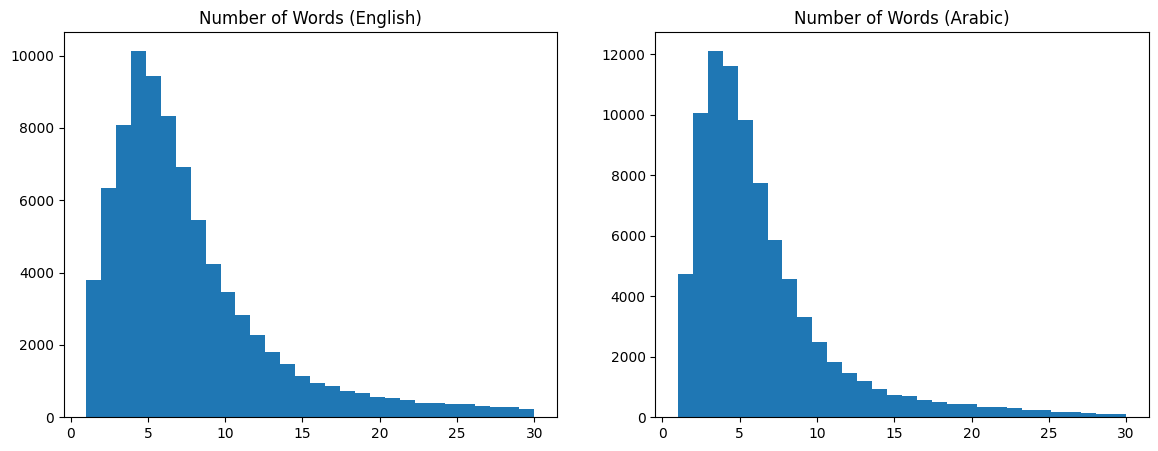

In [105]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(en_sentences_length, bins=30)
axes[0].set_title("Number of Words (English)")

axes[1].hist(ar_sentences_length, bins=30)
axes[1].set_title("Number of Words (Arabic)")
plt.show()

# 2. Load the Data from the 4 Sources

In [ ]:
import pandas as pd
from datasets import load_dataset

def extract_hf_pairs(hf_dataset, num_samples):
    """
    Extracts a specific number of English-Arabic pairs from a Hugging Face dataset.
    Shuffles the data first to ensure a diverse, random sample.
    """
    # Shuffle with a fixed seed for reproducibility
    shuffled_dataset = hf_dataset.shuffle(seed=42)
    
    en_list, ar_list = [], []
    
    for i, row in enumerate(shuffled_dataset):
        if i >= num_samples:
            break
            
        # Hugging Face translation datasets typically store pairs in a nested dictionary
        en_text = row['translation']['en']
        ar_text = row['translation']['ar']
        
        # Basic sanity check to avoid empty strings
        if en_text and ar_text:
            en_list.append(en_text)
            ar_list.append(ar_text)
            
    return en_list, ar_list

def build_master_dataset(custom_file_path):
    """
    Downloads HF datasets, loads the local .txt file, and merges everything.
    """
    master_en = []
    master_ar = []
    
    # 1. Hugging Face: OpenSubtitles (60,000 pairs)
    print("Fetching OpenSubtitles...")
    # Using the standard OPUS wrapper for Hugging Face
    subs_data = load_dataset("opus_books", lang1="ar", lang2="en", split="train")
    en, ar = extract_hf_pairs(subs_data, 60000)
    master_en.extend(en)
    master_ar.extend(ar)
    print(f"Added {len(en)} pairs from OpenSubtitles.")
        
    # 2. Hugging Face: Tatoeba (20,000 pairs)
    print("Fetching Tatoeba...")
    tatoeba_data = load_dataset("tatoeba", lang1="ar", lang2="en", split="train")
    en, ar = extract_hf_pairs(tatoeba_data, 20000)
    master_en.extend(en)
    master_ar.extend(ar)
    print(f"Added {len(en)} pairs from Tatoeba.")
    
    # 3. Hugging Face: Global Voices (20,000 pairs)
    print("Fetching Global Voices...")
    gv_data = load_dataset("global_voices", lang1="ar", lang2="en", split="train")
    en, ar = extract_hf_pairs(gv_data, 20000)
    master_en.extend(en)
    master_ar.extend(ar)
    print(f"Added {len(en)} pairs from Global Voices.")
    
    # 4. Custom Local Dataset (10,000 pairs)
    print(f"Loading custom dataset from {custom_file_path}...")
    # Read the tab-separated file using pandas
    custom_df = pd.read_csv(custom_file_path, sep='\t', header=None, names=['en', 'ar'])
    
    # Drop any rows with missing values (NaN) to prevent type errors downstream
    custom_df = custom_df.dropna()
    
    # Convert dataframe columns to standard Python lists
    custom_en = custom_df['en'].astype(str).tolist()
    custom_ar = custom_df['ar'].astype(str).tolist()
    
    master_en.extend(custom_en)
    master_ar.extend(custom_ar)
    print(f"Added {len(custom_en)} pairs from custom local dataset.")
    
    print("-" * 30)
    print(f"Total raw pairs gathered: {len(master_en)}")
    
    return master_en, master_ar

# ==========================================
# Complete Pipeline Execution
# ==========================================
if __name__ == "__main__":
    # 1. Build the raw merged dataset
    custom_txt_path = "my_custom_dataset.txt" 
    raw_english, raw_arabic = build_master_dataset(custom_txt_path)
    
    # 2. Apply the filtering and normalization from Part 1
    # This guarantees that the final dataset only contains sentences <= 30 words
    # and that the Arabic text is stripped of diacritics and normalized.
    final_en, final_ar = filter_dataset(raw_english, raw_arabic, max_len=30)
    
    print(f"Final training pairs after length filtering: {len(final_en)}")
    
    # From here, you pass `final_en` and `final_ar` into the tokenizer training (Part 1)
    # and then into the PyTorch Dataset class (Part 2).

# 3. Defining the Dataset class

In [42]:
import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

class TranslationDataset(Dataset):
    def __init__(self, src_texts, trg_texts, src_tokenizer, trg_tokenizer):
        self.src_texts = src_texts
        self.trg_texts = trg_texts
        self.src_tokenizer = src_tokenizer
        self.trg_tokenizer = trg_tokenizer
        
        # Extract the special token IDs
        self.src_sos_id = self.src_tokenizer.token_to_id("[SOS]")
        self.src_eos_id = self.src_tokenizer.token_to_id("[EOS]")
        self.trg_sos_id = self.trg_tokenizer.token_to_id("[SOS]")
        self.trg_eos_id = self.trg_tokenizer.token_to_id("[EOS]")

    def __len__(self):
        return len(self.src_texts)

    def __getitem__(self, idx):
        # 1. Get raw strings
        src_text = self.src_texts[idx]
        trg_text = self.trg_texts[idx]

        # 2. Tokenize to IDs
        src_encoded = self.src_tokenizer.encode(src_text).ids
        trg_encoded = self.trg_tokenizer.encode(trg_text).ids

        # 3. Prepend [SOS] and append [EOS]
        src_tensor = torch.tensor([self.src_sos_id] + src_encoded + [self.src_eos_id], dtype=torch.long)
        trg_tensor = torch.tensor([self.trg_sos_id] + trg_encoded + [self.trg_eos_id], dtype=torch.long)

        return src_tensor, trg_tensor

def generate_batch(data_batch, src_pad_idx, trg_pad_idx):
    """
    Collate function to dynamically pad batches.
    Ensures stable tensor shapes for proper mean averaging in the loss function,
    which is especially important if you utilize gradient accumulation later.
    """
    src_batch, trg_batch = [], []
    for src_item, trg_item in data_batch:
        src_batch.append(src_item)
        trg_batch.append(trg_item)
    
    # Dynamically pad the source and target sequences to the max length in THIS batch
    src_padded = pad_sequence(src_batch, padding_value=src_pad_idx, batch_first=True)
    trg_padded = pad_sequence(trg_batch, padding_value=trg_pad_idx, batch_first=True)
    
    return src_padded, trg_padded

# 4. Defining the Model

In [43]:
import torch
import torch.nn as nn
import math

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000, dropout=0.1):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)

        # Create a matrix of shape [max_len, d_model] to hold the positional encodings
        pe = torch.zeros(max_len, d_model)
        
        # Create a column vector of positions [max_len, 1]
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        
        # Calculate the denominator for the sine/cosine arguments
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        
        # Apply sine to even indices, cosine to odd indices
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        
        # Add a batch dimension: [1, max_len, d_model]
        pe = pe.unsqueeze(0)
        
        # Register as a buffer so it saves with the model state but isn't updated by the optimizer
        self.register_buffer('pe', pe)

    def forward(self, x):
        """
        x shape: [batch_size, seq_len, d_model]
        """
        # Add the positional encoding up to the current sequence length
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

class Seq2SeqTransformer(nn.Module):
    def __init__(self, num_encoder_layers, num_decoder_layers, emb_size, 
                 nhead, src_vocab_size, tgt_vocab_size, dim_feedforward, dropout=0.1):
        super(Seq2SeqTransformer, self).__init__()
        
        # Native PyTorch Transformer
        self.transformer = nn.Transformer(
            d_model=emb_size,
            nhead=nhead,
            num_encoder_layers=num_encoder_layers,
            num_decoder_layers=num_decoder_layers,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True # Crucial for our DataLoader configuration
        )
        
        # Linear layer to map the decoder output back to the target vocabulary size
        self.generator = nn.Linear(emb_size, tgt_vocab_size)
        
        # Distinct embedding layers for source (English) and target (Arabic)
        self.src_tok_emb = nn.Embedding(src_vocab_size, emb_size)
        self.tgt_tok_emb = nn.Embedding(tgt_vocab_size, emb_size)
        
        self.positional_encoding = PositionalEncoding(emb_size, dropout=dropout)

    def forward(self, src, trg, src_mask, tgt_mask, src_padding_mask, tgt_padding_mask):
        # Apply embeddings and positional encoding, scaling by sqrt(d_model) as per the paper
        src_emb = self.positional_encoding(self.src_tok_emb(src) * math.sqrt(self.transformer.d_model))
        tgt_emb = self.positional_encoding(self.tgt_tok_emb(trg) * math.sqrt(self.transformer.d_model))
        
        # Pass everything through the Transformer
        outs = self.transformer(
            src_emb, tgt_emb, 
            src_mask=src_mask, tgt_mask=tgt_mask, 
            memory_mask=None, # Usually not needed for standard seq2seq
            src_key_padding_mask=src_padding_mask, 
            tgt_key_padding_mask=tgt_padding_mask,
            memory_key_padding_mask=src_padding_mask
        )
        
        # Project the output to the target vocabulary
        return self.generator(outs)

# Masking Logic

def generate_square_subsequent_mask(sz):
    """
    Creates a look-ahead mask for the decoder to prevent it from "seeing" future tokens.
    Returns a matrix filled with 0s and -inf.
    """
    mask = (torch.triu(torch.ones((sz, sz))) == 1).transpose(0, 1)
    mask = mask.float().masked_fill(mask == 0, float('-inf')).masked_fill(mask == 1, float(0.0))
    return mask

def create_masks(src, tgt, src_pad_idx, tgt_pad_idx):
    """
    Generates both the padding masks and the look-ahead mask.
    """
    src_seq_len = src.shape[1]
    tgt_seq_len = tgt.shape[1]

    # Look-ahead mask for the target sequence
    tgt_mask = generate_square_subsequent_mask(tgt_seq_len)
    
    # The source sequence doesn't need a look-ahead mask, so it's all zeros
    src_mask = torch.zeros((src_seq_len, src_seq_len)).type(torch.bool)

    # Padding masks to ignore [PAD] tokens
    src_padding_mask = (src == src_pad_idx)
    tgt_padding_mask = (tgt == tgt_pad_idx)
    
    return src_mask, tgt_mask, src_padding_mask, tgt_padding_mask

# 5. Training Loop

In [45]:
import torch
import torch.nn as nn
import torch.optim as optim
# import mlflow
from tqdm import tqdm

def train_epoch(model, dataloader, optimizer, loss_fn, device, epoch, accumulation_steps=4):
    model.train()
    total_loss = 0
    
    # Create a progress bar for Kaggle notebooks
    loop = tqdm(dataloader, leave=True, desc=f"Epoch {epoch+1}")
    
    optimizer.zero_grad()
    
    for i, (src, tgt) in enumerate(loop):
        src = src.to(device)
        tgt = tgt.to(device)
        
        # 1. Target Shifting (Teacher Forcing)
        # Input to decoder: everything except the last token [EOS]
        tgt_input = tgt[:, :-1]
        
        # Expected output: everything except the first token [SOS]
        tgt_expected = tgt[:, 1:]
        
        # 2. Create Masks
        src_mask, tgt_mask, src_pad_mask, tgt_pad_mask = create_masks(
            src, tgt_input, SRC_PAD_IDX, TGT_PAD_IDX
        )
        
        # Move masks to device
        src_mask, tgt_mask = src_mask.to(device), tgt_mask.to(device)
        src_pad_mask, tgt_pad_mask = src_pad_mask.to(device), tgt_pad_mask.to(device)
        
        # 3. Forward Pass
        logits = model(src, tgt_input, src_mask, tgt_mask, src_pad_mask, tgt_pad_mask)
        
        # 4. Loss Calculation
        # Flatten the logits and targets for CrossEntropyLoss
        logits = logits.reshape(-1, logits.shape[-1])
        tgt_expected = tgt_expected.reshape(-1)
        
        loss = loss_fn(logits, tgt_expected)
        
        # 5. Dynamic Gradient Accumulation Scaling
        # To ensure proper mean averaging for mini-batch edge cases (the last batch),
        # we dynamically calculate the accumulation divisor.
        remaining_batches = len(dataloader) - i
        current_accum_steps = accumulation_steps if remaining_batches >= accumulation_steps else remaining_batches
        
        scaled_loss = loss / current_accum_steps
        scaled_loss.backward()
        
        # 6. Optimizer Step
        if (i + 1) % accumulation_steps == 0 or (i + 1) == len(dataloader):
            # Gradient clipping to prevent exploding gradients
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            optimizer.zero_grad()
            
        total_loss += loss.item()
        
        # Update progress bar
        loop.set_postfix(loss=loss.item())
        
    return total_loss / len(dataloader)

# 6. Defining the Evaluation Metrics and using the Model for inference

In [20]:
!pip install sacrebleu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 1.5 MB/s eta 0:00:00 0:00:01


In [25]:
import torch
import sacrebleu

def greedy_decode(model, src, src_mask, src_padding_mask, max_len, start_symbol, end_symbol, device):
    """
    Generates a translation token-by-token. 
    Caches the encoder memory to prevent redundant computation.
    """
    model.eval()
    
    with torch.no_grad():
        # 1. Encode the source sentence ONCE
        src_emb = model.positional_encoding(model.src_tok_emb(src) * (model.transformer.d_model ** 0.5))
        memory = model.transformer.encoder(src_emb, mask=src_mask, src_key_padding_mask=src_padding_mask)
        
        # 2. Initialize the target tensor with just the [SOS] token
        ys = torch.ones(1, 1).fill_(start_symbol).type(torch.long).to(device)
        
        for i in range(max_len - 1):
            # Create a new look-ahead mask for the current length of the generated sequence
            tgt_mask = generate_square_subsequent_mask(ys.size(1)).to(device)
            
            # Embed the current target sequence
            tgt_emb = model.positional_encoding(model.tgt_tok_emb(ys) * (model.transformer.d_model ** 0.5))
            
            # 3. Decode
            out = model.transformer.decoder(
                tgt_emb, 
                memory, 
                tgt_mask=tgt_mask,
                memory_key_padding_mask=src_padding_mask
            )
            
            # 4. Project the output of the *last* generated token to the vocabulary space
            logits = model.generator(out[:, -1])
            
            # Select the token with the highest probability
            _, next_word = torch.max(logits, dim=1)
            next_word_id = next_word.item()
            
            # 5. Append the predicted token to the target sequence
            ys = torch.cat([ys, torch.ones(1, 1).type_as(src.data).fill_(next_word_id)], dim=1)
            
            # Stop if the model predicts the End of Sentence token
            if next_word_id == end_symbol:
                break
                
    return ys

def translate(model, src_sentence, src_tokenizer, trg_tokenizer, device, max_len=30):
    """
    Wraps the greedy decoding process: handles string->tensor and tensor->string conversion.
    """
    # Tokenize input string
    src_encoded = src_tokenizer.encode(src_sentence).ids
    src_tensor = torch.tensor([src_tokenizer.token_to_id("[SOS]")] + src_encoded + [src_tokenizer.token_to_id("[EOS]")], dtype=torch.long).unsqueeze(0).to(device)
    
    # Create source masks
    src_mask = torch.zeros((src_tensor.shape[1], src_tensor.shape[1])).type(torch.bool).to(device)
    src_padding_mask = (src_tensor == src_tokenizer.token_to_id("[PAD]")).to(device)
    
    # Generate translation IDs
    trg_tokens = greedy_decode(
        model, src_tensor, src_mask, src_padding_mask, max_len=max_len, 
        start_symbol=trg_tokenizer.token_to_id("[SOS]"), 
        end_symbol=trg_tokenizer.token_to_id("[EOS]"), 
        device=device
    )
    
    # Decode IDs back to a string, skipping special tokens
    trg_ids = trg_tokens.flatten().tolist()
    translation = trg_tokenizer.decode(trg_ids, skip_special_tokens=True)
    
    return translation

# Evaluates only using the Chrf metric
def evaluate_model_metrics(model, test_src_sentences, test_trg_sentences, src_tokenizer, trg_tokenizer, device):
    """
    Evaluates the model and computes both BLEU and chrF++ scores.
    """
    model.eval()
    predictions = []
    
    # Simple loop: unbatched, but clean and reliable for evaluation
    for src_text in test_src_sentences:
        pred_text = translate(model, src_text, src_tokenizer, trg_tokenizer, device)
        predictions.append(pred_text)
        
    # 1. Calculate BLEU score
    # sacrebleu expects references as a list of lists
    bleu = sacrebleu.corpus_bleu(predictions, [test_trg_sentences])
    
    # 2. Calculate chrF++ score
    chrf = sacrebleu.corpus_chrf(predictions, [test_trg_sentences], word_order=2)
    
    return bleu.score, chrf.score, predictions

BLEU = 59.46 75.0/66.7/50.0/50.0 (BP = 1.000 ratio = 1.000 hyp_len = 4 ref_len = 4)


# Experiminting with the Used Datasets, and printing samples of each source

In [18]:
import pandas as pd
from datasets import load_dataset

def print_samples(hf_repo, config_name, num_samples=40):
    print(f"\n{'='*30}")
    print(f"SOURCE: {hf_repo}")
    print(f"{'='*30}")
    
    try:
        # Load the modern Parquet datasets (trust_remote_code is no longer needed)
        dataset = load_dataset(hf_repo, config_name, split="train", streaming=True)
        shuffled = dataset.shuffle(seed=42, buffer_size=1000)
        
        sample_iterator = iter(shuffled)
        for i in range(num_samples):
            row = next(sample_iterator)
            
            # Extract the translations safely
            if 'translation' in row:
                en_text = row['translation']['en']
                ar_text = row['translation']['ar']
            else:
                # Fallback just in case the dataset uses flat keys
                en_text = row.get('en', '')
                ar_text = row.get('ar', '')
                
            print(f"{i+1}. EN: {en_text}")
            print(f"   AR: {ar_text}")
            
    except Exception as e:
        print(f"Could not load {hf_repo}: {e}")
        
def print_local_samples(file_path, num_samples=40):
    print(f"SOURCE: CUSTOM LOCAL DATASET")
    print(f"{'='*30}")
    
    try:
        df = pd.read_csv(file_path, sep='\t', header=None, names=['en', 'ar']).dropna()
        # Sample random rows
        sample_df = df.sample(n=min(num_samples, len(df)), random_state=1)
        
        for i, (_, row) in enumerate(sample_df.iterrows()):
            print(f"{i+1}. EN: {row['en']}")
            print(f"   AR: {row['ar']}")
    except Exception as e:
        print(f"Could not load local file: {e}")

if __name__ == "__main__":
    # 1. IWSLT 2017 (TED Talks - The absolute best for conversational/dialogue translation)
    url = "https://raw.githubusercontent.com/SamirMoustafa/nmt-with-attention-for-ar-to-en/master/ara_.txt"
    response = urllib.request.urlopen(url)
    raw_text = response.read().decode('utf-8')
    custom_file = io.StringIO(raw_text)

    print_local_samples(custom_file, num_samples=10)
    
    print_samples("Helsinki-NLP/opus-100", "ar-en", num_samples=10)
    print_samples("news_commentary", "ar-en", num_samples=10)

SOURCE: CUSTOM LOCAL DATASET
1. EN: I'd rather go swimming.
   AR: أفضّل لو ذهبت للسباحة.
2. EN: You look very tired.
   AR: يبدو عليك التعب.
3. EN: Lack of sleep is bad for your health.
   AR: قلة النوم مضر بصحتك.
4. EN: Tom likes playing chess.
   AR: توم يحب لعب الشطرنج
5. EN: You can't afford to neglect your health.
   AR: لا يسعك أن تهمل صحتك.
6. EN: They are proud of their daughter.
   AR: إنهما فخوران بابنتهما.
7. EN: They did an experiment to see if the drug improved memory.
   AR: قاموا بتجربة لمعرفة ما اذا كان الدواء قد حسن الذاكرة.
8. EN: The pen is broken.
   AR: القلم مكسور.
9. EN: They decided to get married.
   AR: قررا أن يتزوجا.
10. EN: We don't know him.
   AR: نحن لا نعرفه

SOURCE: Helsinki-NLP/opus-100
1. EN: Owen.
   AR: (أوين)
2. EN: We want you to have the first bottle
   AR: نرغب أن تحصلي على هذه القارورة
3. EN: I miss Travis.
   AR: افتقد ترافيس
4. EN: That's nice.
   AR: هذا لطيف
5. EN: Stop it!
   AR: توقف عن ذلك!
6. EN: The fact that the State party could no

# 7. Main Pipeline (Assembling all the Components)

In [32]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
import copy
import pandas as pd
import urllib.request
import io

# Hardware
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Hyperparameters (Designed for small 100k dataset)
VOCAB_SIZE = 10000
MAX_SEQ_LEN = 30
EMB_SIZE = 256
NHEAD = 4
FFN_HID_DIM = 512
NUM_ENCODER_LAYERS = 3
NUM_DECODER_LAYERS = 3
BATCH_SIZE = 64
EPOCHS = 15
LEARNING_RATE = 5e-4
# Optimizer Hparams
WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.1

print(f"--- Starting Pipeline on {DEVICE} ---")

--- Starting Pipeline on cpu ---


In [33]:
# 1. Load, Preprocess, Merge and Filter the Data

url = "https://raw.githubusercontent.com/SamirMoustafa/nmt-with-attention-for-ar-to-en/master/ara_.txt"
response = urllib.request.urlopen(url)
raw_text = response.read().decode('utf-8')
# Convert string to file-like object
custom_file = io.StringIO(raw_text)

# build_and_filter_master_dataset: loads the data from the 3 sources, perform preprocessing, filters the data based on the max word-length of the sentence
final_en_data, final_ar_data = build_and_filter_master_dataset(custom_file, max_len=MAX_SEQ_LEN)

Fetching news_commentary: 100%|██████████| 20000/20000 [00:04<00:00, 4125.08it/s]


Added 10742 pairs from local file.

--- Starting Aggressive Filtering on 110742 raw pairs ---


Cleaning & Filtering: 100%|██████████| 110742/110742 [00:07<00:00, 14627.30it/s]


Invalid pairs count = 17417

Pipeline Complete! Yielded 83171 pristine, NMT-ready pairs.


In [34]:
# 2. SPLIT THE DATA (Train: 90%, Val: 5%, Test: 5%)
en_train, en_temp, ar_train, ar_temp = train_test_split(final_en_data, final_ar_data, test_size=0.10, random_state=1)
en_val, en_test, ar_val, ar_test = train_test_split(en_temp, ar_temp, test_size=0.50, random_state=1)

print(f"Data Split -> Train: {len(en_train)} | Val: {len(en_val)} | Test: {len(en_test)}")

Data Split -> Train: 74853 | Val: 4159 | Test: 4159


In [37]:
# 3. Train Tokenizers on TRAIN SET ONLY (From Part 1)
print("Training Tokenizers...")
en_tokenizer = train_bpe_tokenizer(en_train, vocab_size=VOCAB_SIZE, save_path="en_tokenizer.json")
ar_tokenizer = train_bpe_tokenizer(ar_train, vocab_size=VOCAB_SIZE, save_path="ar_tokenizer.json")

SRC_PAD_IDX = en_tokenizer.token_to_id("[PAD]")
TGT_PAD_IDX = ar_tokenizer.token_to_id("[PAD]")

Training Tokenizers...








In [40]:
# 4. Create Datasets and DataLoaders (From Part 2)
train_dataset = TranslationDataset(en_train, ar_train, en_tokenizer, ar_tokenizer)
val_dataset = TranslationDataset(en_val, ar_val, en_tokenizer, ar_tokenizer)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=lambda x: generate_batch(x, SRC_PAD_IDX, TGT_PAD_IDX))
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=lambda x: generate_batch(x, SRC_PAD_IDX, TGT_PAD_IDX))

In [44]:
# 5. Initialize Model (From Part 3)
print("Initializing Model...")
model = Seq2SeqTransformer(
    NUM_ENCODER_LAYERS, NUM_DECODER_LAYERS, EMB_SIZE, 
    NHEAD, VOCAB_SIZE, VOCAB_SIZE, FFN_HID_DIM
).to(DEVICE)

# 6. Optimizer and Loss
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
loss_fn = nn.CrossEntropyLoss(ignore_index=TGT_PAD_IDX, label_smoothing=LABEL_SMOOTHING)

Initializing Model...


In [47]:
# 7. Training Loop with Model Checkpointing
print("Starting Training...")
best_val_loss = float('inf')
best_model_weights = None

for epoch in range(EPOCHS):
    # train_epoch is from Part 4
    train_loss = train_epoch(model, train_loader, optimizer, loss_fn, DEVICE, epoch, accumulation_steps=4)
    
    # Validation Logic (Simplified forward pass to check loss)
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for src, tgt in val_loader:
            src, tgt = src.to(DEVICE), tgt.to(DEVICE)
            tgt_input = tgt[:, :-1]
            tgt_expected = tgt[:, 1:]
            
            src_mask, tgt_mask, src_pad_mask, tgt_pad_mask = create_masks(src, tgt_input, SRC_PAD_IDX, TGT_PAD_IDX)
            src_mask, tgt_mask = src_mask.to(DEVICE), tgt_mask.to(DEVICE)
            src_pad_mask, tgt_pad_mask = src_pad_mask.to(DEVICE), tgt_pad_mask.to(DEVICE)
            
            logits = model(src, tgt_input, src_mask, tgt_mask, src_pad_mask, tgt_pad_mask)
            loss = loss_fn(logits.reshape(-1, logits.shape[-1]), tgt_expected.reshape(-1))
            val_loss += loss.item()
            
    val_loss /= len(val_loader)
    print(f"Epoch {epoch+1} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
    
    # Save the best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_weights = copy.deepcopy(model.state_dict())
        torch.save(model.state_dict(), "best_transformer_arabic.pth")
        print("  -> New best model saved!")

In [ ]:
# 8. Load Best Model for Evaluation
print("\nLoading best model for Test Set Evaluation...")
model.load_state_dict(best_model_weights)

In [ ]:
# 10. Final Evaluation on unseen Test Set (From Part 5)
# Note: evaluate_model_metrics is the function we built that returns BLEU and chrF++
bleu, chrf, _ = evaluate_model_metrics(model, en_test, ar_test, en_tokenizer, ar_tokenizer, DEVICE)
print(f"\nFinal Test Results -> BLEU: {bleu:.2f} | chrF++: {chrf:.2f}")

In [ ]:
# 11. Inference Demo
test_sentence = "How are you today?"
translation = translate(model, test_sentence, en_tokenizer, ar_tokenizer, DEVICE)
print(f"\nDemo Translation:")
print(f"EN: {test_sentence}")
print(f"AR: {translation}")